# 05 — Evaluación Final del Agente Racional

**Objetivo:** cargar ambos modelos entrenados, evaluarlos sobre el conjunto de test y generar el reporte final.

Este notebook consolida métricas y visualizaciones de los dos componentes del agente:
- **Regresión:** ¿Cuántos días tardará el pedido?
- **Clasificación:** ¿Existe riesgo de retraso?

In [2]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data/processed')
MODELS_DIR = Path('../models')
OUT_DIR    = Path('../outputs/graficas')

## 1. Cargar datos y modelos

In [3]:
test = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'preprocesadores.pkl', 'rb') as f:
    prep = pickle.load(f)

FEATURES_NUM = prep['features_num']
FEATURES_CAT = prep['features_cat']

modelo_reg  = keras.models.load_model(MODELS_DIR / 'modelo_regresion.keras')
modelo_clf  = keras.models.load_model(MODELS_DIR / 'modelo_clasificacion.keras')

print(f'Test: {len(test):,} muestras')

Test: 9,619 muestras


In [4]:
# Preparar inputs
X_num = test[FEATURES_NUM].values.astype('float32')
X_cat = [test[col].values.astype('int32') for col in FEATURES_CAT]
X_test = [X_num] + X_cat

y_dias  = test['dias_entrega'].values.astype('float32')
y_retraso = test['es_retraso'].values.astype('float32')

## 2. Métricas — Regresión

In [5]:
pred_dias = modelo_reg.predict(X_test).flatten()

mae  = mean_absolute_error(y_dias, pred_dias)
rmse = np.sqrt(mean_squared_error(y_dias, pred_dias))
r2   = r2_score(y_dias, pred_dias)

print('=== Regresión: Días de Entrega ===')
print(f'  MAE:  {mae:.2f} días')
print(f'  RMSE: {rmse:.2f} días')
print(f'  R²:   {r2:.4f}')

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Regresión: Días de Entrega ===
  MAE:  3.26 días
  RMSE: 4.39 días
  R²:   0.1546


## 3. Métricas — Clasificación

In [6]:
pred_prob  = modelo_clf.predict(X_test).flatten()
pred_clase = (pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_retraso, pred_prob)
f1  = f1_score(y_retraso, pred_clase)

print('=== Clasificación: Riesgo de Retraso ===')
print(f'  AUC-ROC: {auc:.4f}')
print(f'  F1-Score: {f1:.4f}')
print()
print(classification_report(y_retraso, pred_clase, target_names=['A tiempo', 'Retraso']))

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Clasificación: Riesgo de Retraso ===
  AUC-ROC: 0.5565
  F1-Score: 0.0326

              precision    recall  f1-score   support

    A tiempo       0.91      0.93      0.92      8797
     Retraso       0.04      0.03      0.03       822

    accuracy                           0.85      9619
   macro avg       0.47      0.48      0.48      9619
weighted avg       0.84      0.85      0.84      9619



## 4. Visualizaciones

c:\Users\ADMIN\AppData\Local\Altair\MF\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


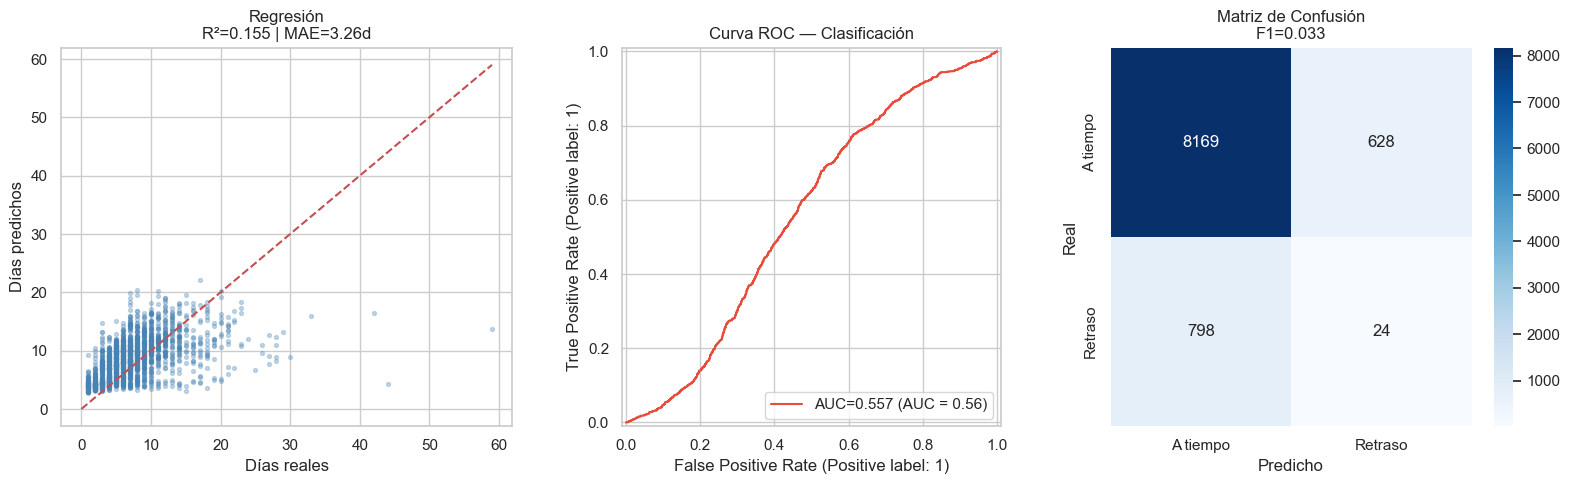

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Scatter: real vs predicho (regresión) ---
idx = np.random.choice(len(y_dias), min(2000, len(y_dias)), replace=False)
axes[0].scatter(y_dias[idx], pred_dias[idx], alpha=0.3, s=8, color='steelblue')
lim = max(y_dias.max(), pred_dias.max())
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlabel('Días reales')
axes[0].set_ylabel('Días predichos')
axes[0].set_title(f'Regresión\nR²={r2:.3f} | MAE={mae:.2f}d')

# --- Curva ROC ---
RocCurveDisplay.from_predictions(
    y_retraso, pred_prob, ax=axes[1],
    name=f'AUC={auc:.3f}', color='#e74c3c'
)
axes[1].set_title('Curva ROC — Clasificación')

# --- Matriz de confusión ---
cm = confusion_matrix(y_retraso, pred_clase)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['A tiempo', 'Retraso'],
    yticklabels=['A tiempo', 'Retraso'],
    ax=axes[2]
)
axes[2].set_xlabel('Predicho')
axes[2].set_ylabel('Real')
axes[2].set_title(f'Matriz de Confusión\nF1={f1:.3f}')

plt.tight_layout()
plt.savefig(OUT_DIR / 'evaluacion_final.png', dpi=120)
plt.show()

## 5. Guardar métricas finales

In [8]:
metricas = {
    'regresion': {
        'mae_dias':  round(float(mae), 4),
        'rmse_dias': round(float(rmse), 4),
        'r2':        round(float(r2), 4)
    },
    'clasificacion': {
        'auc_roc':   round(float(auc), 4),
        'f1_score':  round(float(f1), 4),
        'n_retrasos_reales':    int(y_retraso.sum()),
        'n_retrasos_predichos': int(pred_clase.sum())
    }
}

with open('../outputs/metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

print('Métricas guardadas en outputs/metricas.json')
print(json.dumps(metricas, indent=2))

Métricas guardadas en outputs/metricas.json
{
  "regresion": {
    "mae_dias": 3.2555,
    "rmse_dias": 4.3901,
    "r2": 0.1546
  },
  "clasificacion": {
    "auc_roc": 0.5565,
    "f1_score": 0.0326,
    "n_retrasos_reales": 822,
    "n_retrasos_predichos": 652
  }
}


## 6. Demostración: inferencia sobre un pedido nuevo

Simulación de cómo el agente trabajaría con datos de entrada reales.

In [9]:
# Tomar el primer registro del test como ejemplo (ya está escalado/codificado)
ejemplo_num = X_num[[0]]
ejemplo_cat = [c[[0]] for c in X_cat]
ejemplo_input = [ejemplo_num] + ejemplo_cat

dias_pred    = modelo_reg.predict(ejemplo_input, verbose=0).flatten()[0]
prob_retraso = modelo_clf.predict(ejemplo_input, verbose=0).flatten()[0]

print('=== Predicción del Agente ===')
print(f'  ETA estimado:      {dias_pred:.1f} días')
print(f'  Riesgo de retraso: {prob_retraso:.1%}')
print(f'  Decisión agente:   {"⚠️ RETRASO PROBABLE" if prob_retraso >= 0.5 else "✅ ENTREGA A TIEMPO"}')
print()
print(f'  Valor real: {y_dias[0]:.0f} días | Retraso real: {"Sí" if y_retraso[0] == 1 else "No"}')

=== Predicción del Agente ===
  ETA estimado:      10.5 días
  Riesgo de retraso: 20.8%
  Decisión agente:   ✅ ENTREGA A TIEMPO

  Valor real: 8 días | Retraso real: No


## 7. Resumen de resultados

### Métricas obtenidas

| Modelo | Métrica | Resultado | Umbral objetivo |
|---|---|---|---|
| Regresión | MAE | 3.26 días | < 5 días |
| Regresión | RMSE | 4.39 días | — |
| Regresión | R² | 0.1546 | > 0.50 |
| Clasificación | AUC-ROC | 0.5565 | > 0.70 |
| Clasificación | F1-Score | 0.0326 | > 0.40 |

### Análisis

**Regresión (ETA):**
El modelo alcanza un MAE de 3.26 días, lo que significa que en promedio se equivoca en poco más de 3 días. Sin embargo, el R² de 0.15 indica que el modelo solo explica el 15% de la varianza en los tiempos de entrega, por debajo del umbral objetivo de 0.50. El modelo captura cierta señal pero la mayor parte de la variabilidad queda sin explicar.

**Clasificación (riesgo de retraso):**
El AUC-ROC de 0.56 está apenas por encima del azar (0.50), y el F1-Score de 0.03 es muy bajo. El modelo detectó 652 retrasos frente a 822 reales, pero con alta tasa de falsos negativos. El desbalance de clases (solo ~8% de retrasos en el dataset) hace que este sea el problema más difícil de los dos.

### Posibles causas y mejoras

- **R² bajo en regresión:** la distancia Haversine y las features físicas capturan la geografía, pero factores como la capacidad del transportista, la ruta real o el día festivo no están disponibles en el dataset. Agregar el tiempo de procesamiento del seller (desde compra hasta envío al carrier) podría mejorar significativamente el modelo.
- **Clasificación débil:** con solo ~8% de retrasos, el modelo tiende a predecir siempre "a tiempo". Explorar umbrales de clasificación distintos a 0.5, oversampling (SMOTE) o aumentar el `class_weight` podría mejorar el recall en la clase minoritaria.
- **Arquitectura:** incrementar la profundidad o añadir más features derivadas (por ejemplo, tiempo seller-a-carrier como proxy de eficiencia del vendedor) son los siguientes pasos naturales.
